In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pipeline.pipeline import PreprocessingPipeline
from pipeline.preprocessors.revised_missing import RevisedMissingValueHandler
from pipeline.preprocessors.numerical import Scaler
from pipeline.preprocessors.categorical import CategoricalEncoder
from pipeline.preprocessors.features import FeatureEngineer


# Health Data Preprocessing Pipeline

## Overview
A modular, automated preprocessing pipeline for tabular health datasets.
Designed to handle the common data quality challenges found in clinical data, missing values, inconsistent scaling, and categorical variables and produce clean, machine-learning-ready outputs in a reproducible and reusable way.

Built as a portfolio project demonstrating skills relevant to health data science research, using the Pima Indians Diabetes dataset as a case study.

## 1. Raw Data
- Download **diabetes.csv** data from https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database
- This dataset is originally from the National Institute of Diabetes and Digestive and Kidney Diseases.
- The objective of the dataset is to diagnostically predict whether or not a patient has diabetes, based on certain diagnostic measurements included in the dataset.
- Several constraints were placed on the selection of these instances from a larger database. In particular, all patients here are females at least 21 years old of Pima Indian heritage.
- The dataset consists of several medical predictor (independent) variables and one target (dependent) variable, **Outcome**.

In [2]:
# Load data
df = pd.read_csv('../../data/diabetes.csv')

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## 2. Data Quality Issues
- Contains no explicit null values, they are instead 0's.
- Five columns contain 0's that are biologically impossible: **Glucose, BloodPressure, SkinThickness, BMI, and Insulin**
- They represent missing values recorded as 0.

In [5]:
# View 0 count per column
(df == 0).sum()

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

The distributions below reveal the extent of the data quality issues.
Biologically impossible columns show an artificial spike at zero representing missing values. The pipeline corrects these distortions.

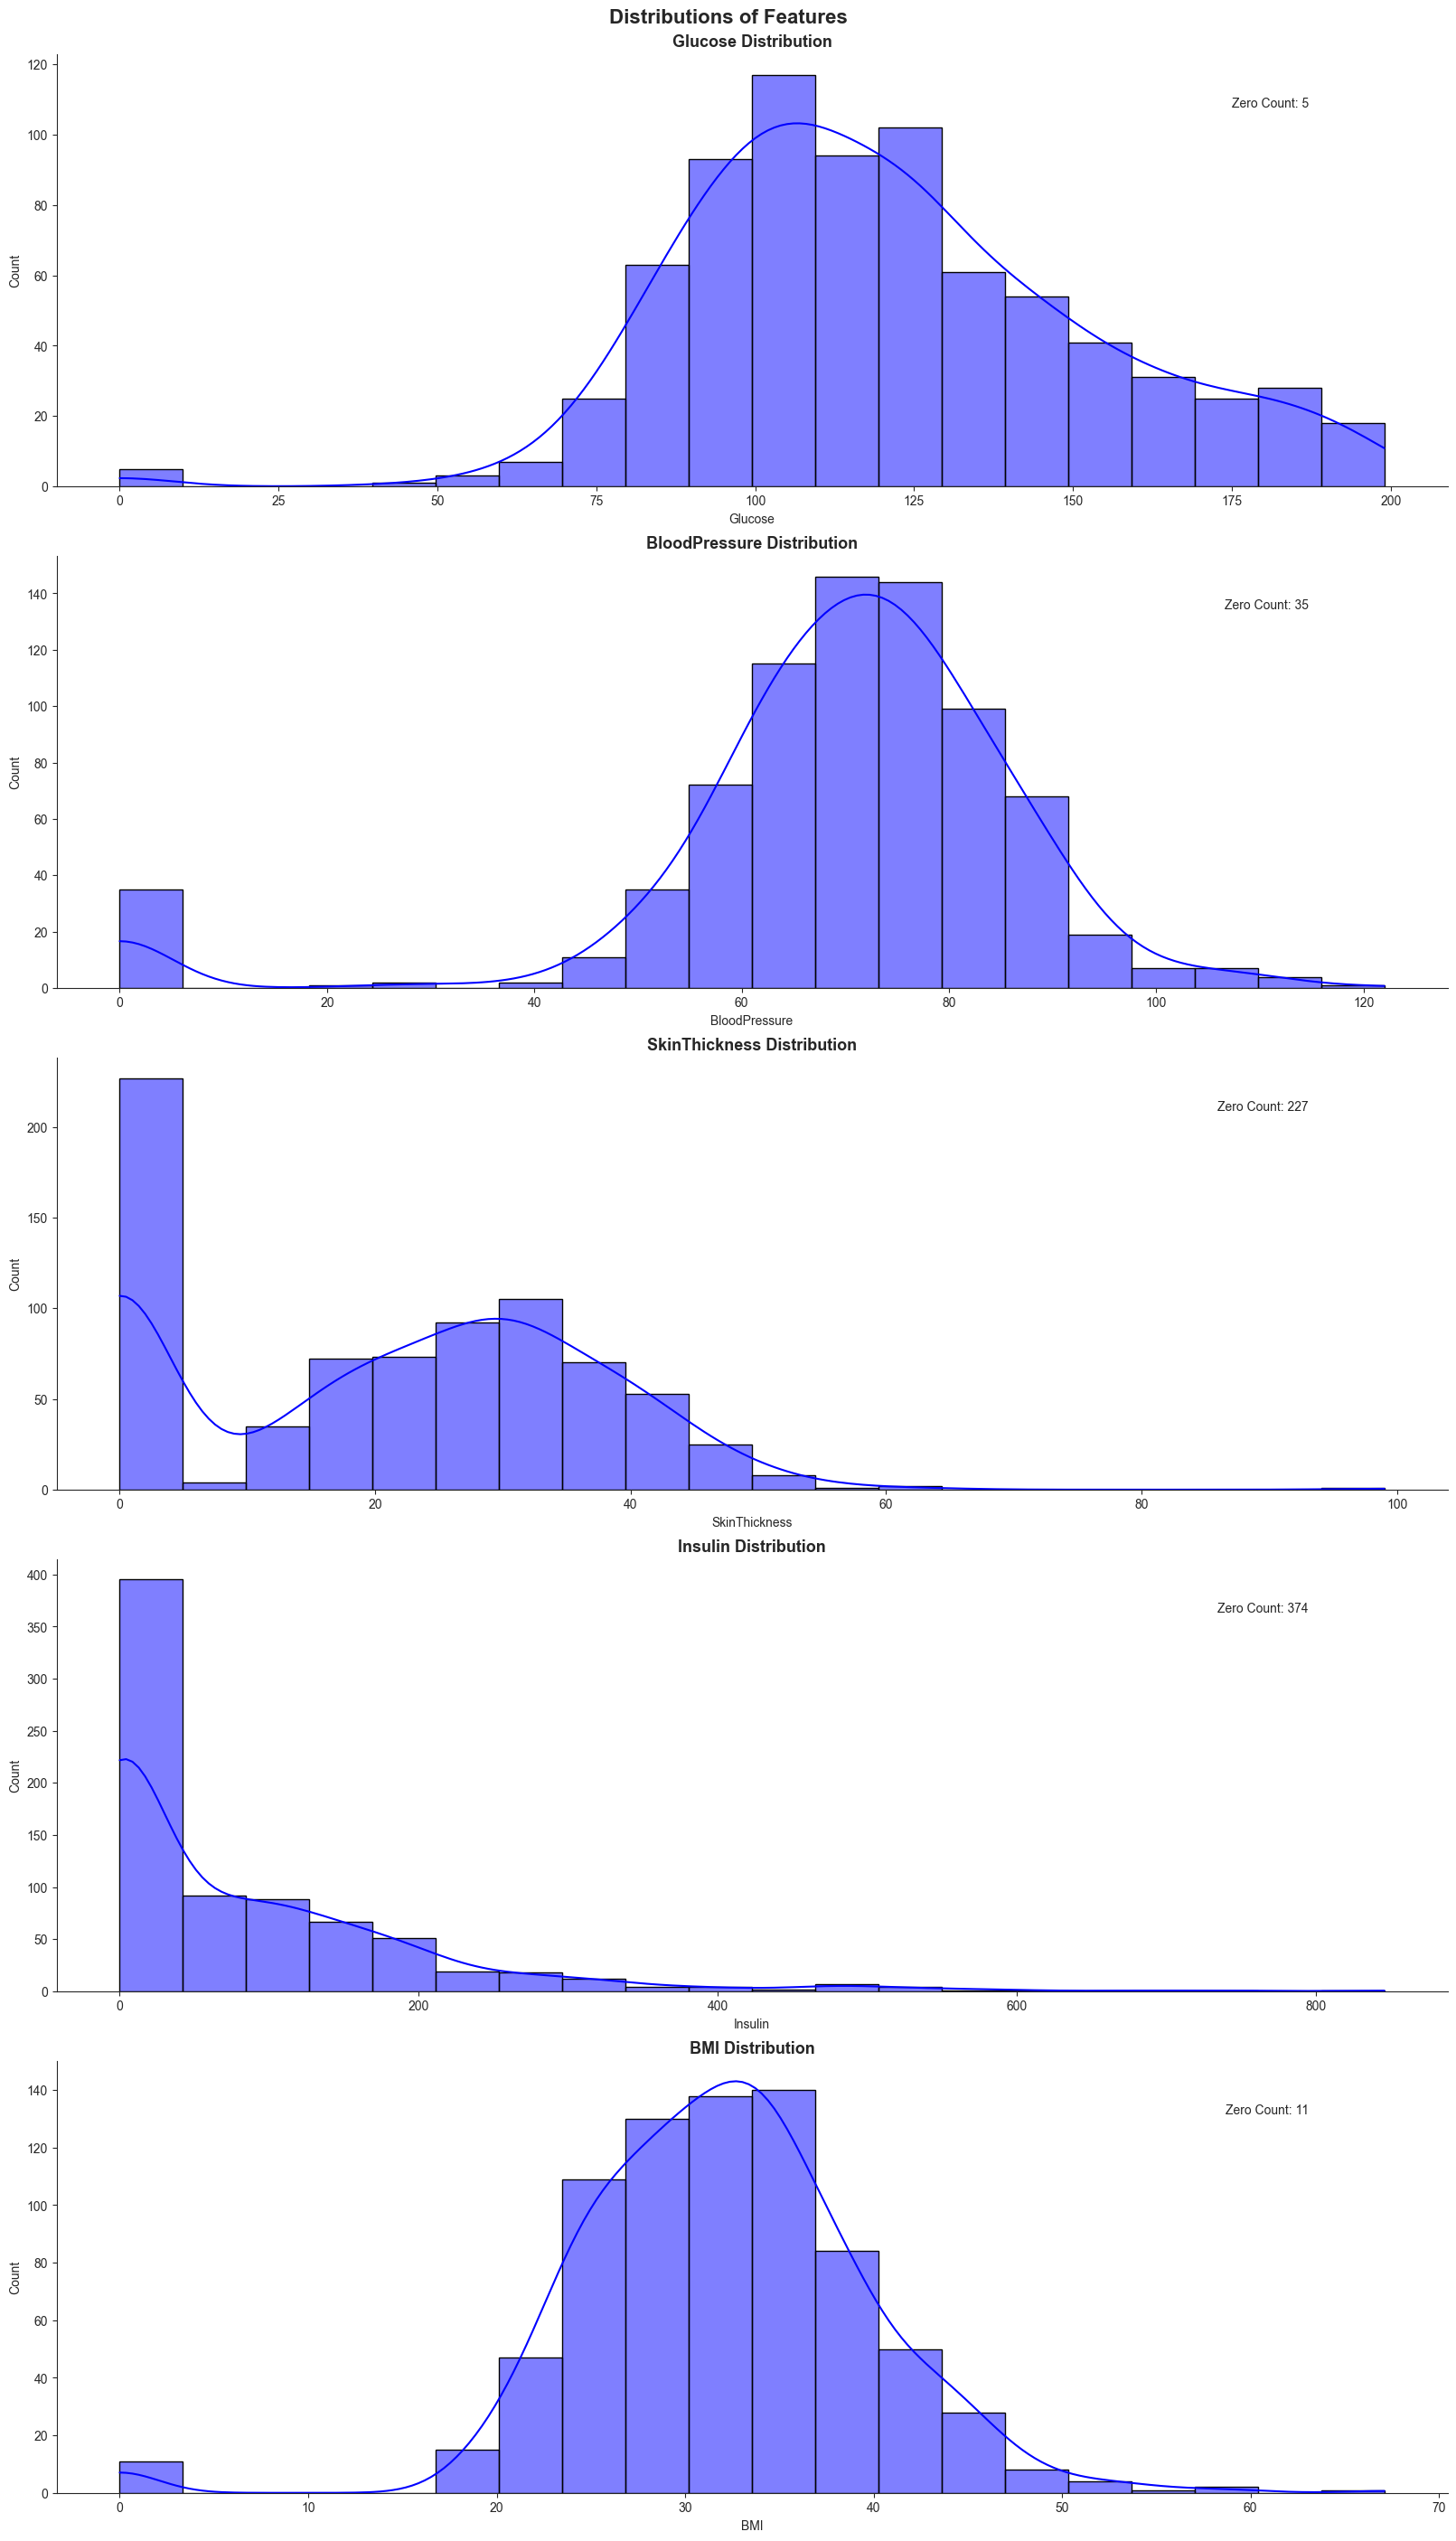

In [18]:
# Visualise distributions of data
demo_cols = [col for col in df.columns if col not in ['Outcome','Pregnancies','DiabetesPedigreeFunction','Age']]
fig, axes = plt.subplots(len(demo_cols), 1, figsize=(16, 28), constrained_layout=True)

for ax, col in zip(axes, demo_cols):
    zero_count = (df[col] == 0).sum()
    sns.histplot(df[col], bins=20, kde=True, color='blue', edgecolor='black', ax=ax)
    ax.set_title(f'{col} Distribution', fontsize=13, fontweight='bold')
    ax.set_ylabel('Count')
    ax.annotate(f'Zero Count: {zero_count}', xy=(0.9, 0.9), xycoords='axes fraction', ha='right', va='top')

plt.suptitle('Distributions of Features', fontsize=16, fontweight='bold')
sns.despine()
plt.show()

Glucose, BloodPressure, and BMI follow approximately normal distributions
once zeros are removed. SkinThickness is right skewed with 29.5% missing values, making it a candidate for KNN imputation over simple median imputation.

## 3. Pipeline Configuration

The pipeline runs three sequential steps:

1. **Missing value handling:** Rows with two or more biologically impossible zeros are dropped. Insulin is removed entirely (48% missing). Remaining missing values are imputed automatically: KNN for columns with >20% missing, median for skewed distributions, mean for normal distributions.

2. **Scaling:** Numerical features are standardised using StandardScaler so no column dominates model training due to scale differences.

3. **Feature engineering and encoding:** BMI is categorised using official `WHO` thresholds (Underweight/Healthy/Overweight/Obese) and ordinally encoded to preserve the clinical progression. ranges. https://www.diabetes.co.uk/bmi.html

In [19]:
# Define the biologically impossible set for imputation
impossibles = ['Glucose', 'BloodPressure', 'SkinThickness', 'BMI']

In [22]:
# Create the pipeline
pipeline = PreprocessingPipeline(
    missing_value_handler=RevisedMissingValueHandler(
        drop_cols=['Insulin'],
        impute_cols=impossibles,
        zero_cols=impossibles
    ),
    numerical_scaler=Scaler(
        scale_cols=['Glucose', 'BloodPressure', 'SkinThickness',
                    'BMI', 'Pregnancies', 'DiabetesPedigreeFunction', 'Age']
    ),
    categorical_encoder=CategoricalEncoder(
        nominal_cols=[],
        ordinal_cols={'BMICategory': ['Underweight', 'Healthy', 'Overweight', 'Obese']}
    ),
    feature_engineer=FeatureEngineer()
)

df_clean = pipeline.fit_transform(df)
df_clean.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,BMI,DiabetesPedigreeFunction,Age,Outcome,BMICategory
0,0.635626,0.857470,-0.029161,6.501609e-01,0.163790,0.450630,1.423376,1,3.0
1,-0.848175,-1.202734,-0.515471,-1.706081e-02,-0.855381,-0.375786,-0.194857,0,2.0
2,1.229146,2.002028,-0.677574,3.950746e-16,-1.335847,0.585372,-0.109687,1,1.0
3,-0.848175,-1.071927,-0.515471,-6.842825e-01,-0.636987,-0.926730,-1.046559,0,2.0
4,-1.144936,0.497752,-2.622814,6.501609e-01,1.546951,5.424097,-0.024517,1,3.0


## 4. Results
The pipeline reduced the dataset from 768 to 733 rows by removing records with excessive missing values. All remaining missing values were imputed. Scaled columns have mean ≈ 0 and standard deviation ≈ 1 confirming StandardScaler applied correctly.

In [28]:
# Compare preprocessed data to raw data
print(f'Raw data: {df.shape[0]} rows, {df.shape[1]} columns')
print(f'Clean data: {df_clean.shape[0]} rows, {df_clean.shape[1]} columns')
print(f'Rows removed: {df.shape[0] - df_clean.shape[0]}')

Raw data: 768 rows, 9 columns
Clean data: 733 rows, 9 columns
Rows removed: 35


In [27]:
# Check for 0 values in the scaled set
(df_clean == 0).sum()

Pregnancies                   0
Glucose                       0
BloodPressure                 2
SkinThickness                 0
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                     481
BMICategory                   4
dtype: int64

In [29]:
df_clean.describe().round(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,BMI,DiabetesPedigreeFunction,Age,Outcome,BMICategory
count,733.00,733.00,733.00,733.00,733.00,733.00,733.00,733.00,733.00
mean,-0.00,-0.00,-0.00,0.00,0.00,0.00,-0.00,0.34,2.48
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.48,0.74
min,-1.14,-2.54,-3.92,-2.46,-2.08,-1.19,-1.05,0.00,0.00
25%,-0.85,-0.71,-0.68,-0.57,-0.72,-0.69,-0.79,0.00,2.00
50%,-0.25,-0.16,-0.03,0.00,-0.01,-0.29,-0.37,0.00,3.00
75%,0.64,0.63,0.62,0.43,0.60,0.46,0.66,1.00,3.00
max,3.90,2.53,4.02,7.77,5.04,5.82,4.06,1.00,3.00


## 5. Comparison
- **Glucose:** Only a small number of imputations using the mean, so the distribution remained similar.
- **BloodPressure:** Imputed using the mean, the distribution remains normal.
- **SkinThickness:** Imputed using KNN, which provided a similar result as imputing with the median. However, the number of imputations was higher than other columns; this data is artificially spiked.
- **BMI:** Imputation seems to skew the distribution.
- **Insulin:** Removed entirely.

All features are now scaled to a standard range (mean ≈ 0, std ≈ 1),
removing the influence of differing measurement scales on downstream
machine learning models.

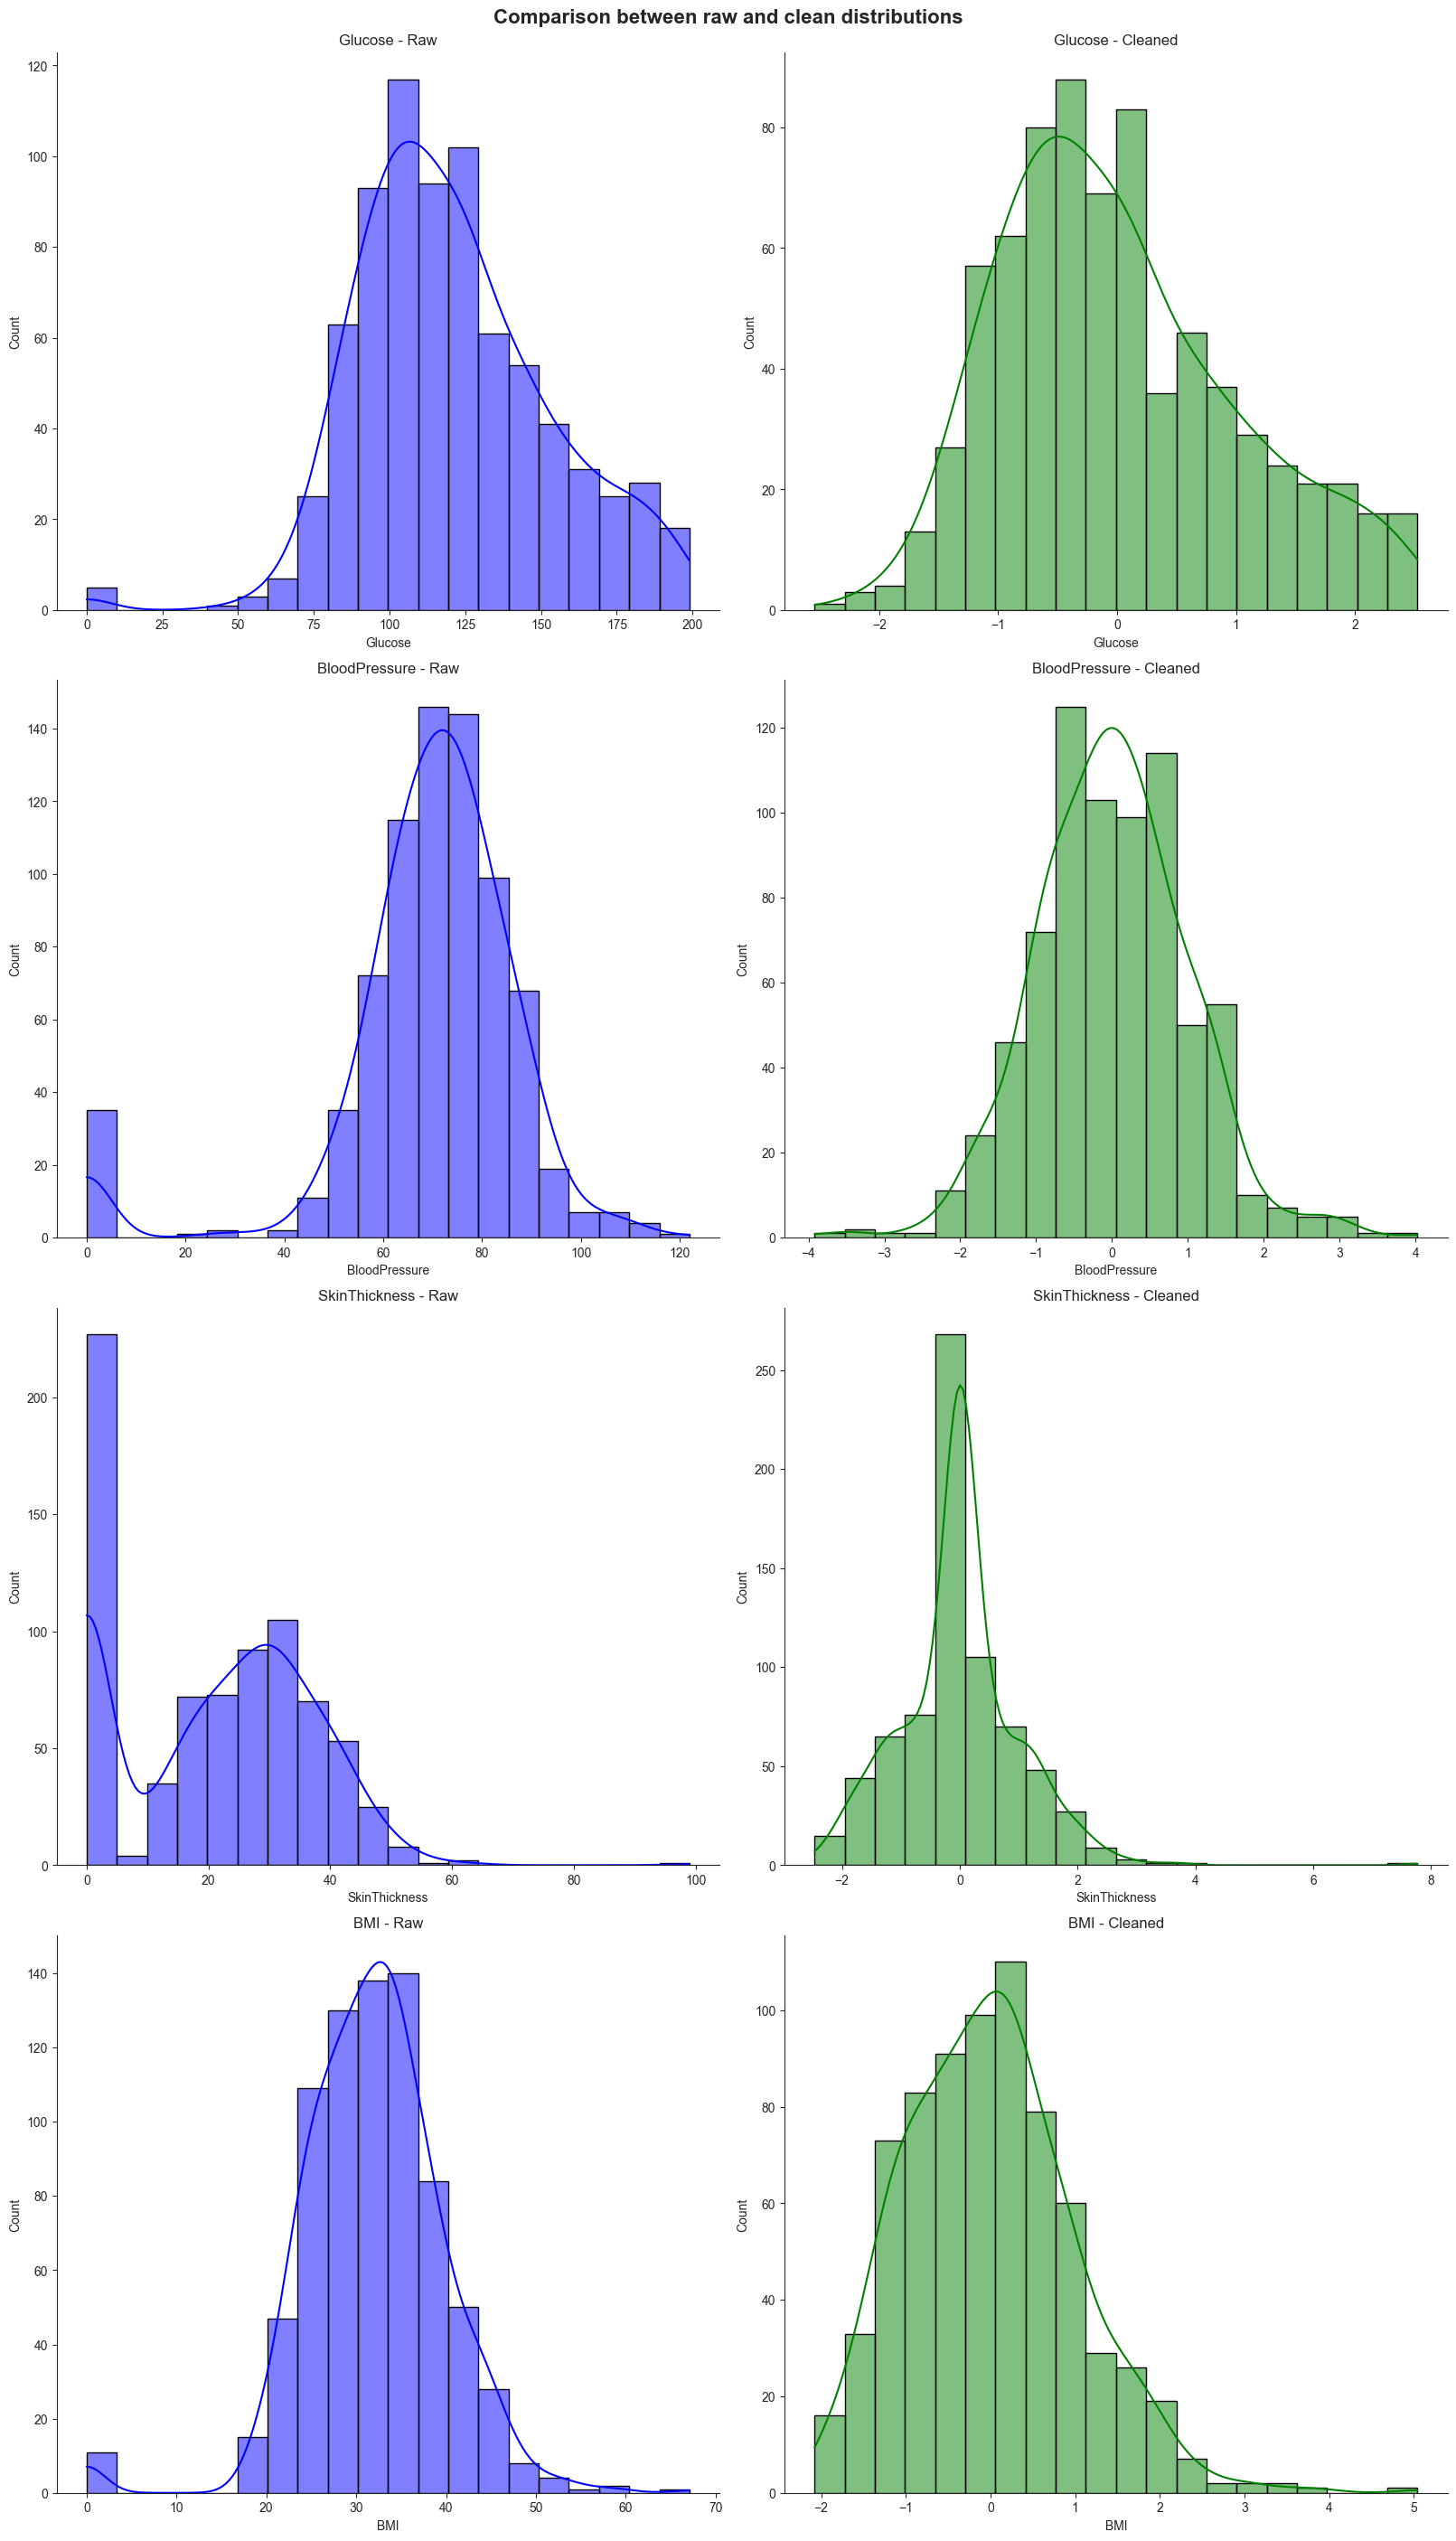

In [32]:
# Visualise distributions of data
fig, axes = plt.subplots(len(impossibles), 2, figsize=(16, 28), constrained_layout=True)

for i, col in enumerate(impossibles):
    # Plot raw on the left
    sns.histplot(df[col], bins=20, kde=True,
                 color='blue', edgecolor='black', ax=axes[i, 0])
    axes[i, 0].set_title(f'{col} - Raw')

    # Plot cleaned on the right
    sns.histplot(df_clean[col],  bins=20, kde=True,
                 color='green', edgecolor='black', ax=axes[i, 1])
    axes[i, 1].set_title(f'{col} - Cleaned')

plt.suptitle('Comparison between raw and clean distributions', fontsize=16, fontweight='bold')
sns.despine()
plt.show()